In [1]:
import pandas as pd
import pylab as pl
import numpy as np
import scipy.optimize as opt
import statsmodels.api as sm
from sklearn import preprocessing
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import seaborn as sns

#Data Preparation

Loading the Dataset

In [2]:
df = pd.read_csv('framingham.csv')

In [3]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [4]:
df.drop(['education'], inplace= True, axis =1)

In [5]:
df.rename({'male':'sex_male'}, inplace=True)

Handling Missing Values

In [6]:
# removing NaN / NULL values
df.dropna(axis=0, inplace=True)

Splitting the Dataset into Test and Train Sets

In [7]:
x = df.drop(['TenYearCHD'], axis=1)
y = df['TenYearCHD']
# normalization of the dataset
x = preprocessing.StandardScaler().fit(x).transform(x)

from sklearn.model_selection import train_test_split
x_train , x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state= 42)
x_test.shape
y_train.shape

(3000,)

Exploratory Data Analysis of Heart Disease Dataset

C:\Users\User\AppData\Local\Temp\ipykernel_9512\4103168201.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='TenYearCHD', data=df, palette='BuGn_r')


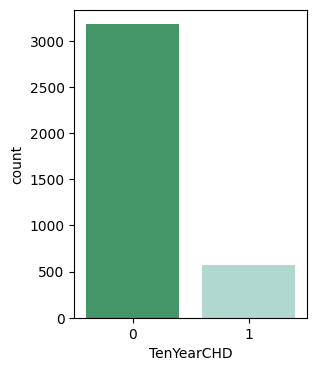

In [8]:
# counting no. of patients affected with CHD
plt.figure(figsize=(3,4))
sns.countplot(x='TenYearCHD', data=df, palette='BuGn_r')
plt.show()

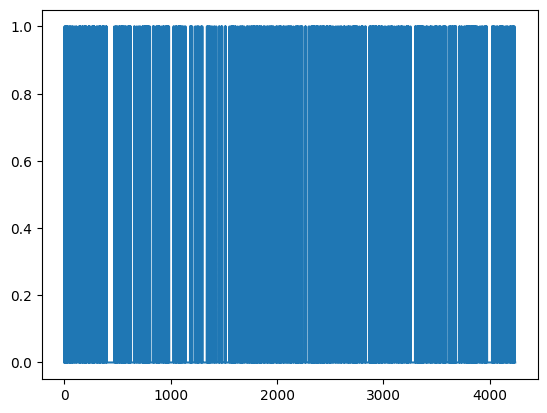

In [9]:
laste = df['TenYearCHD'].plot()
plt.show(laste)

Fitting Logistic Regression Model for Heart Disease Prediction

In [10]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train, y_train)
y_predict = model.predict(x_train)

Evaluating Logistic Regression Model



In [11]:
from sklearn.metrics import accuracy_score
accuracy_score(y_train, y_predict)

0.8603333333333333

Confusion Matrix



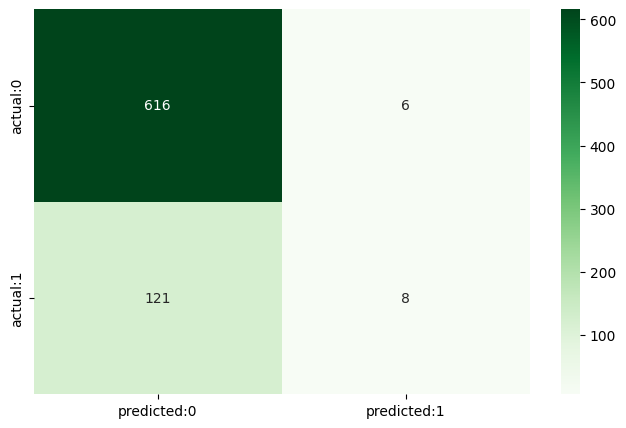

In [12]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, model.predict(x_test))
confs_matrix = pd.DataFrame(data =cm,
                            columns = ['predicted:0', 'predicted:1'],
                            index = ['actual:0', 'actual:1'])
plt.figure(figsize=(8,5))
sns.heatmap(confs_matrix, annot = True, fmt = 'd', cmap = 'Greens')
plt.show()